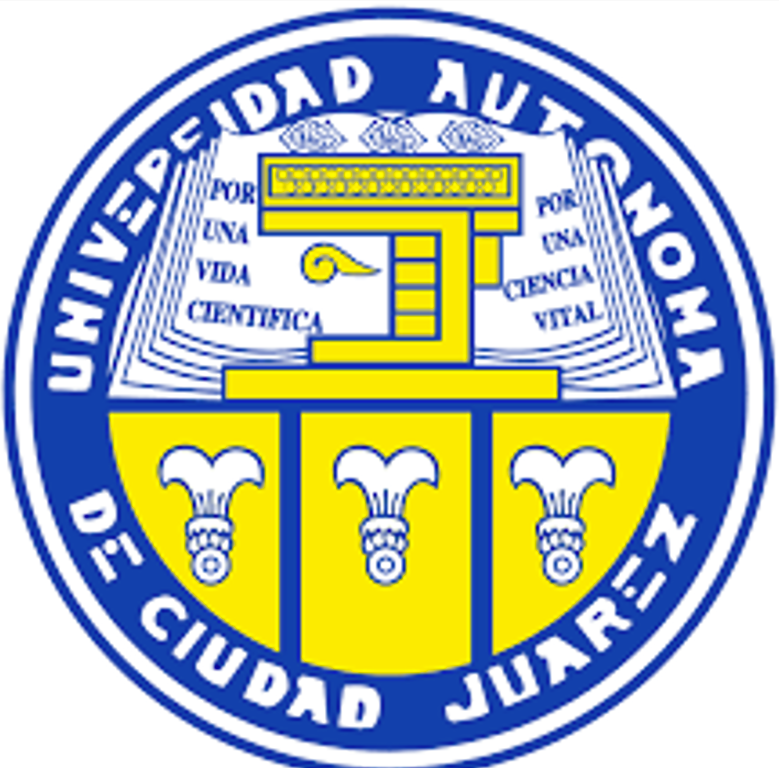


# Titulo: Implementación de Redes Neuronales Recurrentes - Predicciones de Precios de Acciones. 
# Nombre: Sergio Trejo
# Matricula: 261539
# Materia: Redes neuronales profundas_A_Presencial_260206

**En archivo comprimido compartido contiene una base de datos de precios de acciones de distintas empresas (un archivo para cada empresa). La información de cada archivo está estructurada de la siguiente manera:**

**El objetivo de este ejercicio es implementar una red neuronal recurrente para predecir el valor más bajo de una acción (columna Low) tomando como referencia un historial de valores de días previos. Cada estudiante puede elegir libremente el archivo de la empresa con la que trabajará.**

Instrucciones:
1. División del conjunto de datos

    * Use los datos desde el inicio hasta el año 2016 como conjunto de entrenamiento.

    * Use los datos del año 2017 en adelante como conjunto de prueba.

2. Implementación del modelo

    * Se proporciona un archivo base de programación que les permitirá:

        *  Leer los archivos de datos.

        *  Construir los conjuntos de entrenamiento y prueba.

        * Definir y entrenar una red neuronal recurrente.

3. Pruebas a realizar

    * Entrene y evalúe un modelo usando celdas LSTM.

    * Entrene y evalúe un modelo usando celdas GRU.

    * En ambos casos, realice las pruebas considerando:

        * Un historial de 30 días previos.

        * Un historial de 50 días previos.

4. Resultados a reportar

    * Registre las curvas comparativas entre los valores esperados y los valores predichos por cada modelo.

    * Calcule y reporte el valor de RMSE (Root Mean Square Error) para cada prueba.

    * Compare y discuta los resultados obtenidos entre:

        * Modelos con LSTM vs GRU.

        * Uso de 30 días vs 50 días de historial.

In [33]:
# Importing the libraries

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU
from keras.optimizers import SGD
from keras import activations
import math
from sklearn.metrics import mean_squared_error

In [34]:
# cargar dataset
path_file = "DataSets/AMZN_2006-01-01_to_2018-01-01.csv"
dataset1 = pd.read_csv(path_file, index_col='Date', parse_dates=['Date'])
dataset1.head()  

dataset = dataset1.dropna()  # Eliminar cualquier fila con NaN en cualquier columna

#Division de entrenamiento y prueba
training_set = dataset.loc[:'2016', ["Low"]].values  # modificar dependiendo de la tarea
test_set = dataset.loc['2017':, ["Low"]].values   # modificar dependiendo de la tarea

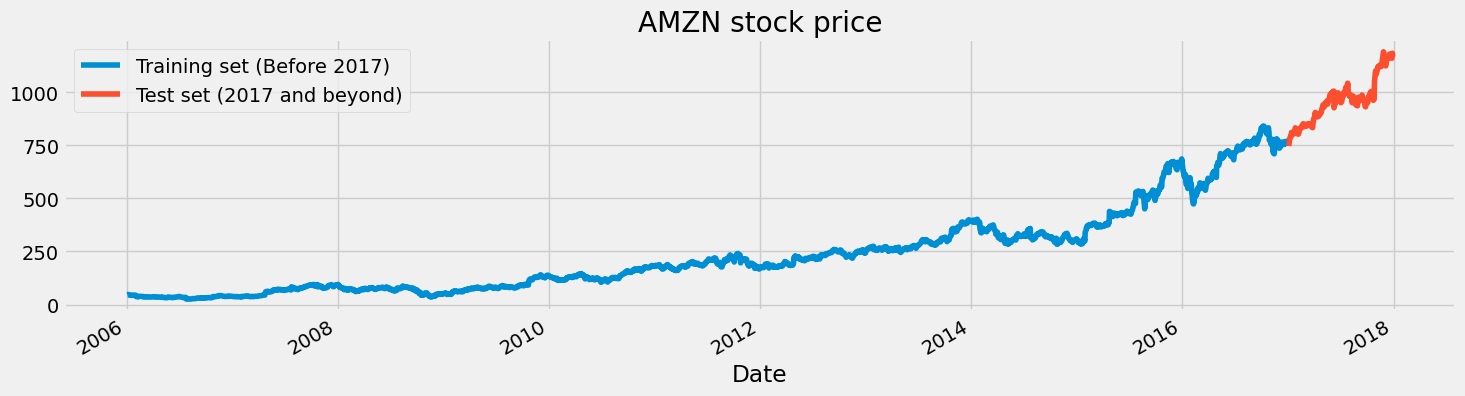

In [35]:
# We have chosen 'Low' attribute for prices. Let's see what it looks like

dataset["Low"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["Low"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('AMZN stock price')
plt.show()

In [36]:
# Scaling the training set
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

# we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements 
X_train = []
y_train = []
previous_days = 30  # cantidad de días previos usados para la predicción
N = training_set.shape[0]

for i in range(previous_days,N):
    X_train.append(training_set_scaled[i-previous_days:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [37]:
# Reshaping X_train 
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],1))  

## LTSM - 30 Días

In [38]:

regressor = Sequential()

# First LSTM layer with Dropout regularisation
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))

# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Third LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Fourth LSTM layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Output layer
regressor.add(Dense(units=1, activation='linear'))

# Compile model
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

regressor.summary()

/home/sergioai/miniconda3/envs/ml/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Fitting to the training set
regressor.fit(X_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0076
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0039
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0032
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0025  
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0024
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0022
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 397ms/step - loss: 0.0020
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ -31s -366396us/step - loss: 0.0020
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0017
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0018


In [40]:
# get the test set ready in a similar way as the training set.
dataset_total = pd.concat((dataset["Low"][:'2016'],dataset["Low"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - previous_days:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

# Preparing X_test and predicting the prices
X_test = []
N1 = inputs.shape[0]
for i in range(previous_days,N1):
    X_test.append(inputs[i-previous_days:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))

In [41]:
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


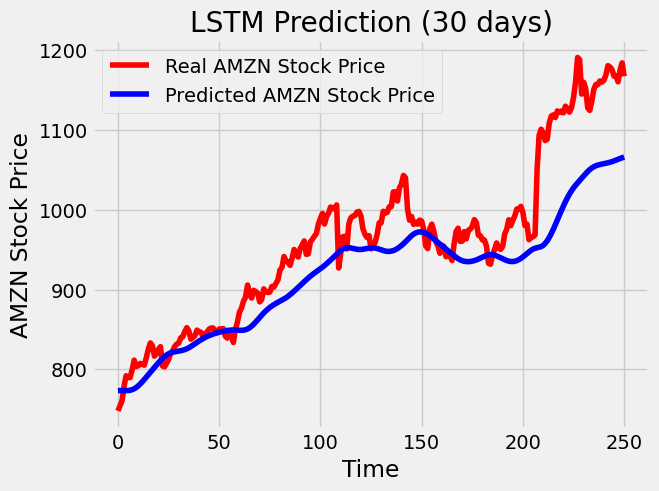

RMSE LSTM 30: 58.31952627099353


In [42]:
plt.plot(test_set, color='red',label='Real AMZN Stock Price')
plt.plot(predicted_stock_price, color='blue',label='Predicted AMZN Stock Price')
plt.title('LSTM Prediction (30 days)')
plt.xlabel('Time')
plt.ylabel('AMZN Stock Price')
plt.legend()
plt.show()
# Evaluating our model
rmse_lstm30 = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
print("RMSE LSTM 30:", rmse_lstm30)

## LSTM - 50 Días

In [43]:
# we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements 
X_train = []
y_train = []
previous_days = 50  # cantidad de días previos usados para la predicción
N = training_set.shape[0]

for i in range(previous_days,N):
    X_train.append(training_set_scaled[i-previous_days:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [44]:

regressor = Sequential()

# First LSTM layer with Dropout regularisation
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))

# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Third LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Fourth LSTM layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Output layer
regressor.add(Dense(units=1, activation='linear'))

# Compile model
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

regressor.summary()

/home/sergioai/miniconda3/envs/ml/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 50, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 50, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Fitting to the training set
regressor.fit(X_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0086
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0044 
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0031
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0030
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0023
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0022
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0020  
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0018
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0017
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0020


In [46]:
# get the test set ready in a similar way as the training set.
dataset_total = pd.concat((dataset["Low"][:'2016'],dataset["Low"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - previous_days:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

# Preparing X_test and predicting the prices
X_test = []
N1 = inputs.shape[0]
for i in range(previous_days,N1):
    X_test.append(inputs[i-previous_days:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))

In [47]:
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


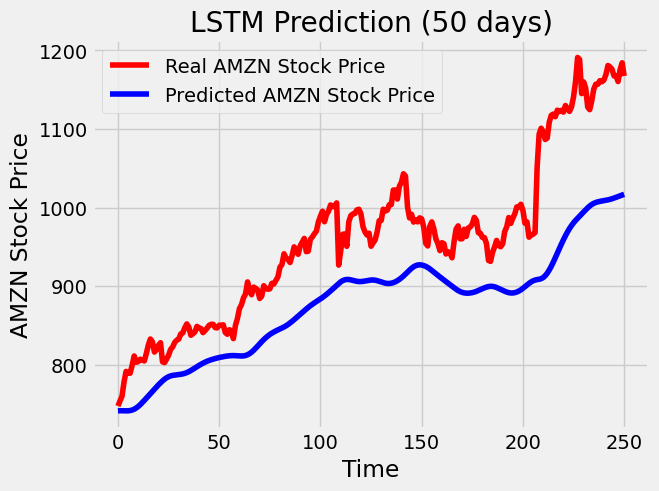

RMSE LSTM 50: 93.67412335536388


In [48]:
plt.plot(test_set, color='red',label='Real AMZN Stock Price')
plt.plot(predicted_stock_price, color='blue',label='Predicted AMZN Stock Price')
plt.title('LSTM Prediction (50 days)')
plt.xlabel('Time')
plt.ylabel('AMZN Stock Price')
plt.legend()
plt.show()
# Evaluating our model
rmse_lstm50 = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
print("RMSE LSTM 50:", rmse_lstm50)

## GRU — 30 días

In [49]:
# we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements 
X_train = []
y_train = []
previous_days = 30  # cantidad de días previos usados para la predicción
N = training_set.shape[0]

for i in range(previous_days,N):
    X_train.append(training_set_scaled[i-previous_days:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
#Modelo con GRU
regressor = Sequential()

regressor.add(GRU(50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))

regressor.add(GRU(50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(GRU(50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(GRU(50))
regressor.add(Dropout(0.2))

regressor.add(Dense(1))

# Compiling the RNN
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')
regressor.summary()

/home/sergioai/miniconda3/envs/ml/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_8 (GRU)                     │ (None, 30, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 30, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_10 (GRU)                    │ (None, 30, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_11 (GRU)                    │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,901 (210.55 KB)

 Trainable params: 53,901 (210.55 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Fitting to the training set
regressor.fit(X_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0071  
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0033
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0035
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0029  
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0022
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0022
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0022  
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0021
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0021
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0020  


In [52]:
# get the test set ready in a similar way as the training set.
dataset_total = pd.concat((dataset["Low"][:'2016'],dataset["Low"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - previous_days:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

# Preparing X_test and predicting the prices
X_test = []
N1 = inputs.shape[0]
for i in range(previous_days,N1):
    X_test.append(inputs[i-previous_days:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))

In [53]:
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


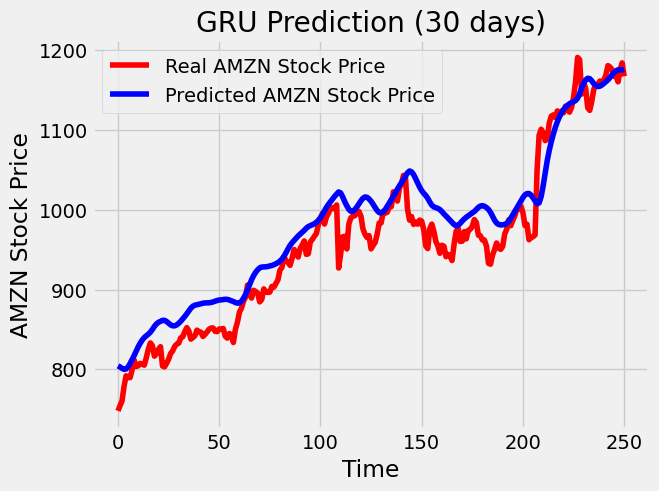

RMSE GRU 30: 32.61526614355264


In [54]:
plt.plot(test_set, color='red',label='Real AMZN Stock Price')
plt.plot(predicted_stock_price, color='blue',label='Predicted AMZN Stock Price')
plt.title('GRU Prediction (30 days)')
plt.xlabel('Time')
plt.ylabel('AMZN Stock Price')
plt.legend()
plt.show()
# Evaluating our model
rmse_gru30 = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
print("RMSE GRU 30:", rmse_gru30)

## GRU — 50 días

In [55]:
# we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements 
X_train = []
y_train = []
previous_days = 50  # cantidad de días previos usados para la predicción
N = training_set.shape[0]

for i in range(previous_days,N):
    X_train.append(training_set_scaled[i-previous_days:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
#Modelo con GRU
regressor = Sequential()

regressor.add(GRU(50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))

regressor.add(GRU(50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(GRU(50, return_sequences=True))
regressor.add(Dropout(0.2))

regressor.add(GRU(50))
regressor.add(Dropout(0.2))

regressor.add(Dense(1))

# Compiling the RNN
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')
regressor.summary()

/home/sergioai/miniconda3/envs/ml/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_12 (GRU)                    │ (None, 50, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_13 (GRU)                    │ (None, 50, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_14 (GRU)                    │ (None, 50, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_15 (GRU)                    │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,901 (210.55 KB)

 Trainable params: 53,901 (210.55 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Fitting to the training set
regressor.fit(X_train,y_train,epochs=10,batch_size=32)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0089 
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0036
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0027  
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0027
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0025  
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0022
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0022  
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0019
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0019
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0017


In [58]:
# get the test set ready in a similar way as the training set.
dataset_total = pd.concat((dataset["Low"][:'2016'],dataset["Low"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - previous_days:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

# Preparing X_test and predicting the prices
X_test = []
N1 = inputs.shape[0]
for i in range(previous_days,N1):
    X_test.append(inputs[i-previous_days:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))

In [59]:
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step 


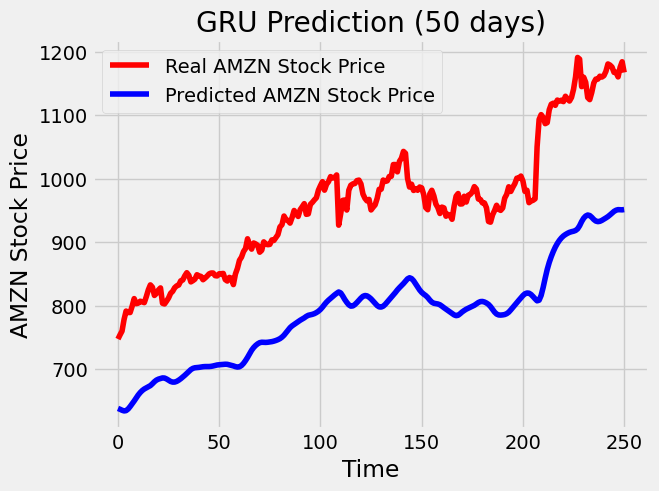

RMSE GRU 50: 176.19863607882647


In [60]:
plt.plot(test_set, color='red',label='Real AMZN Stock Price')
plt.plot(predicted_stock_price, color='blue',label='Predicted AMZN Stock Price')
plt.title('GRU Prediction (50 days)')
plt.xlabel('Time')
plt.ylabel('AMZN Stock Price')
plt.legend()
plt.show()
# Evaluating our model
rmse_gru50 = math.sqrt(mean_squared_error(test_set, predicted_stock_price))
print("RMSE GRU 50:", rmse_gru50)

In [61]:
print("RMSE Results")

print("LSTM 30 days:", rmse_lstm30)
print("LSTM 50 days:", rmse_lstm50)
print("GRU 30 days:", rmse_gru30)
print("GRU 50 days:", rmse_gru50)

results = pd.DataFrame({
    "Model": ["LSTM","LSTM","GRU","GRU"],
    "History Days":[30,50,30,50],
    "RMSE":[rmse_lstm30, rmse_lstm50, rmse_gru30, rmse_gru50]
})

results

RMSE Results
LSTM 30 days: 58.31952627099353
LSTM 50 days: 93.67412335536388
GRU 30 days: 32.61526614355264
GRU 50 days: 176.19863607882647


,Model,History Days,RMSE
0,LSTM,30,58.319526
1,LSTM,50,93.674123
2,GRU,30,32.615266
3,GRU,50,176.198636


## Resultados A Reportar

**Comparacion entre LSTM y GRU**

* En los experimentos realizados se entrenaron modelos utilizando celdas LSTM y GRU para predecir el valor minimo de la accion. De acuerdo con los resultados obtenidos, el modelo GRU con un historial de 30 dias obtuvo el menor error RMSE (32.61), lo que nos dice que fue el modelo con mejor performance para este data set.

* En comparacion, el modelo LSTM con 30 dias obtuvo un RMSE mayor (58.31), lo que nos dice que en este caso que el modelo GRU fue capaz de aprender mejor el comportamiento de la serie temporal.

* Esto puede deberse a que las celdas GRU tienen una estructura mas simple que las LSTM, lo cual en algunos problemas puede permitir que el modelo aprenda de manera mas eficiente.

**Comparacion entre 30 dias y 50 dias de historial**

* Tambien se evaluo el efecto de utilizar diferentes tamaños de historial para entrenar los modelos. En ambos casos, tanto para LSTM como para GRU, el uso de 30 dias de historial dio mejores resultados que utilizar 50 dias.

* Por ejemplo, el modelo LSTM paso de un RMSE de 58.31 con 30 dias a 93.67 con 50 dias. El modelo GRU tmabien aumento su error de 32.61 a 176.19 cuando se utilizaron 50 dias de historial.

* Esto nos dice que para este conjunto de datos un historial demasiado largo puede introducir ruido o informacion menos relevante para la prediccion del precio de la accion.

**Conclusiones**

* De acuerdo con los resultados obtenidos, el mejor modelo fue GRU utilizando un historial de 30 dias, ya que obtuvo el menor valor de RMSE. En general, los modelos con 30 dias de historial mostraron mejor performance que los modelos con 50 dias.

* Estos resultados indican que tanto la arquitectura del modelo como el tamaño de la ventana temporal utilizada para entrenar la red neuronal pueden influir significativamente en la calidad de las predicciones.
